- Vi bruger absolut-værdi af signalet for at se hvor meget af en given frekvens, der optræder i signalet


- Vi normaliserer med signalets længde, så vi kan sammenligne FFT spektre med ANDRE FFT spektre (fra andre signaler), fordi FFT skalerer med N, som er længden af signalet (skal lige dobbeltjekke formulering)


- Vi shift'er signalet (så vi har negative værdier på venstre side), fordi det er nemmere at læse. Ellers ville de optræde på højre side af de positive værdier (efter Nyquist-frekvensen)


- Peak ved 0 Hz er DC-komponent og (bør) svare til middelværdien af inputsignalet


- Når vi definerer signalet er vi nødt til at lave det om fra bitarray til liste, ellers laver FFT ged i det. Det ses ved at middelværdien bliver alt for høj


- Almost all of the enrgy is contained in the main lobe. Side lobes are leakage. Main lobe determines band-width?


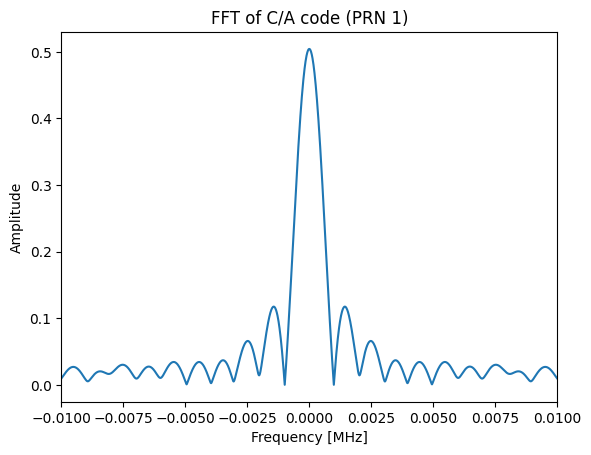

In [20]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift
import functions
import importlib
importlib.reload(functions)

from functions import *


code = np.array(ca_code(1).tolist())        # skal være en liste, ellers bliver det weird
chip_rate = 1.023e6
N = len(code)
NFFT = 1023 * 100  # zero-pad to 100x more points


X = fft(code, n=NFFT)  # n= pads with zeros automatically
freq = fftfreq(NFFT, 1 / chip_rate)
freq_shift = fftshift(freq)
X_shift = fftshift(X)
magn = np.abs(X_shift) / N  # still normalize by original length


plt.plot(freq_shift / 1e6, magn)
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude')
plt.xlim([-0.01, 0.01])
plt.title('FFT of C/A code (PRN 1)')
plt.show()


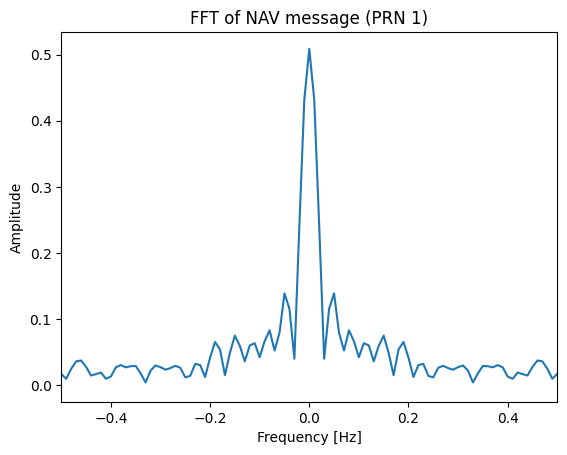

0.5086666666666667


In [21]:
chip_rate = 50      # Hz
frames = np.array(((append_parity(frame(1,1,Z_count_start))[0])[:]).tolist())
N = len(frames)
NFFT = chip_rate * 100                      # 0-pad to get more points


X_frames = fft(frames, n=NFFT)
X_frames_shift = fftshift(X_frames)


f = fftfreq(NFFT, 1 / chip_rate)           # d 1/sample rate, in this case sample rate == bit rate. d = T_bit
f_shift = fftshift(f)


magni = np.abs(X_frames_shift) / N


plt.plot(f_shift, magni)     
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim([-0.5, 0.5])
plt.title('FFT of NAV message (PRN 1)')
plt.show()
print(np.mean(frames))

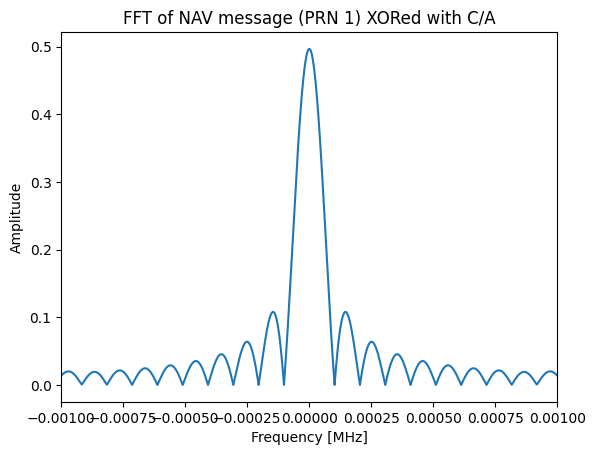

In [22]:
# NAV med C/A


chip_rate = 1.023e6      # Hz
sammen = np.array((res[0:10000]).tolist())
N = len(sammen)
NFFT = int(chip_rate * 100)                      # 0-pad to get more points


X_sammen = fft(sammen, n=NFFT)
X_sammen_shift = fftshift(X_sammen)


f = fftfreq(NFFT, 1 / chip_rate)           # d 1/sample rate, in this case sample rate == bit rate. d = T_bit
f_shift = fftshift(f)


magni = np.abs(X_sammen_shift) / N


plt.plot(f_shift / 1e6, magni)     
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude')
plt.xlim([-0.001, 0.001])
plt.title('FFT of NAV message (PRN 1) XORed with C/A')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

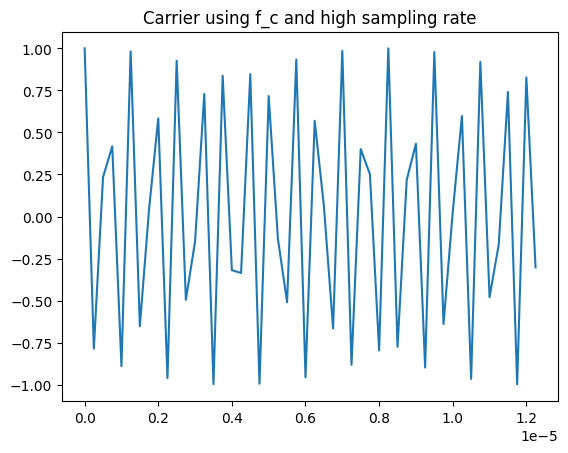

In [23]:
# Carrier


chip_rate = 1.023e6
fs = 4.0e9             # desto højere, desto mere zoomer vi ind
f_if = 1.25e6
fc = 1575.42e6
n_plot = 50              # samples     


t_plot = np.arange(n_plot) / fs
#carrier = np.cos(2 * np.pi *f_if* t_plot).astype(np.float32)
carrier = np.cos(2 * np.pi *fc* t_plot).astype(np.float32)


plt.plot(t_plot * 1e3, carrier)
plt.title("Carrier using f_c and high sampling rate")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

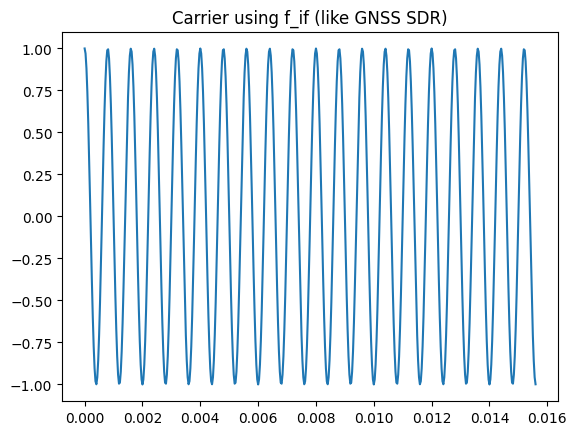

In [24]:
# Carrier 2


chip_rate = 1.023e6
fs = 8*4.0e6             # desto højere, desto mere zoomer vi ind
f_if = 1.25e6
fc = 1575.42e6
n_plot = 500              # samples     


t_plot = np.arange(n_plot) / fs
carrier = np.cos(2 * np.pi *f_if* t_plot).astype(np.float32)




plt.plot(t_plot * 1e3, carrier)
plt.title("Carrier using f_if (like GNSS SDR)")
plt.show